In [3]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config
from matplotlib import rcParams, rcParamsDefault
import matplotlib.colors as mcolors
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"


config_path = "configs/default.yaml"
config = get_config(config_path)

seed = config["seed"]
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [5]:
from scripts.utils import bin_and_padding

for _eid in ['E118','E116','E003']:
    # data = pd.read_csv(f'extra/results/{_eid}_predictions_bs_bf.csv')
    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{_eid}.csv"

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')

    high_gene_ids = list(meta[meta['bf_label']==1][['gene_id','strand']].values)
    high_marks_list = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
    
    with open(f"benchmarks/revised_v2/reviewer3/results/{_eid}_bf_para_highmarks.npy", 'wb') as f:
        np.save(f,high_marks_list)

    low_gene_ids = list(meta[meta['bf_label']==0][['gene_id','strand']].values)
    low_marks_list = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
    with open(f"benchmarks/revised_v2/reviewer3/results/{_eid}_bf_para_lowmarks.npy", 'wb') as f:
        np.save(f,low_marks_list)


In [46]:
import numpy as np
import pandas as pd
from pathlib import Path

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
EIDS = ["E118", "E116", "E003"]

EID_NAME = {
    "E118": "HepG2",
    "E116": "GM12878",
    "E003": "H1",
}

MARKS = [
    "H3K4me1",
    "H3K4me3",
    "H3K9me3",
    "H3K27me3",
    "H3K36me3",
    "H3K27ac",
    "H3K9ac",
]

result_dir = Path("benchmarks/revised_v2/reviewer3/results")

out_dir = result_dir / "bf_bs_mark_boxplots"
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_context("paper")

In [48]:
def load_label_mark_values(eid, label_type, result_dir, marks):
    """
    Load high/low mark arrays for one label type: BF or BS.

    Expected files:
        {eid}_bf_para_highmarks.npy
        {eid}_bf_para_lowmarks.npy
        {eid}_bs_para_highmarks.npy
        {eid}_bs_para_lowmarks.npy

    Array shape:
        [n_genes, 7, n_bins]

    Returns:
        long-format DataFrame with columns:
        eid, cell_type, label_type, group, mark, value
    """
    label_lower = label_type.lower()

    high_path = result_dir / f"{eid}_{label_lower}_para_highmarks.npy"
    low_path = result_dir / f"{eid}_{label_lower}_para_lowmarks.npy"

    if not high_path.exists():
        raise FileNotFoundError(f"Missing file: {high_path}")
    if not low_path.exists():
        raise FileNotFoundError(f"Missing file: {low_path}")

    high_arr = np.load(high_path)
    low_arr = np.load(low_path)

    print(
        f"{eid} {label_type}: "
        f"high={high_arr.shape}, low={low_arr.shape}"
    )

    records = []

    for mark_idx, mark in enumerate(marks):
        high_values = np.nanmean(high_arr[:, mark_idx, :], axis=1)
        low_values = np.nanmean(low_arr[:, mark_idx, :], axis=1)

        high_values = high_values[np.isfinite(high_values)]
        low_values = low_values[np.isfinite(low_values)]

        for v in high_values:
            records.append({
                "eid": eid,
                "cell_type": EID_NAME.get(eid, eid),
                "label_type": label_type,
                "group": "High",
                "mark": mark,
                "value": v,
            })

        for v in low_values:
            records.append({
                "eid": eid,
                "cell_type": EID_NAME.get(eid, eid),
                "label_type": label_type,
                "group": "Low",
                "mark": mark,
                "value": v,
            })

    return pd.DataFrame(records)

In [49]:
all_df = []

for eid in EIDS:
    for label_type in ["BF", "BS"]:
        df = load_label_mark_values(
            eid=eid,
            label_type=label_type,
            result_dir=result_dir,
            marks=MARKS,
        )
        all_df.append(df)

plot_df = pd.concat(all_df, ignore_index=True)

save_path = out_dir / "bf_bs_high_low_mark_mean_values_long_table.csv"
plot_df.to_csv(save_path, index=False)

print(f"[Saved] {save_path}")
plot_df.head()

E118 BF: high=(7149, 7, 80), low=(7158, 7, 80)
E118 BS: high=(7158, 7, 80), low=(7149, 7, 80)
E116 BF: high=(7699, 7, 80), low=(8166, 7, 80)
E116 BS: high=(8104, 7, 80), low=(7761, 7, 80)
E003 BF: high=(7309, 7, 80), low=(7111, 7, 80)
E003 BS: high=(7110, 7, 80), low=(7310, 7, 80)
[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/bf_bs_high_low_mark_mean_values_long_table.csv


,eid,cell_type,label_type,group,mark,value
0,E118,HepG2,BF,High,H3K4me1,0.356938
1,E118,HepG2,BF,High,H3K4me1,0.139405
2,E118,HepG2,BF,High,H3K4me1,0.226739
3,E118,HepG2,BF,High,H3K4me1,1.010945
4,E118,HepG2,BF,High,H3K4me1,0.413764


In [50]:
test_records = []

for (eid, cell_type, mark, label_type), sub in plot_df.groupby(
    ["eid", "cell_type", "mark", "label_type"]
):
    high_values = sub.loc[sub["group"] == "High", "value"].values
    low_values = sub.loc[sub["group"] == "Low", "value"].values

    high_values = high_values[np.isfinite(high_values)]
    low_values = low_values[np.isfinite(low_values)]

    stat, p_value = mannwhitneyu(
        high_values,
        low_values,
        alternative="two-sided",
    )

    test_records.append({
        "eid": eid,
        "cell_type": cell_type,
        "mark": mark,
        "label_type": label_type,
        "n_high": len(high_values),
        "n_low": len(low_values),
        "mean_high": np.mean(high_values),
        "mean_low": np.mean(low_values),
        "median_high": np.median(high_values),
        "median_low": np.median(low_values),
        "mean_high_minus_low": np.mean(high_values) - np.mean(low_values),
        "mannwhitney_u": stat,
        "p_value": p_value,
    })

test_df = pd.DataFrame(test_records)

test_df["fdr"] = multipletests(
    test_df["p_value"].values,
    method="fdr_bh",
)[1]

test_path = out_dir / "bf_bs_high_low_mannwhitney_test.csv"
test_df.to_csv(test_path, index=False)

print(f"[Saved] {test_path}")
test_df.head()

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/bf_bs_high_low_mannwhitney_test.csv


,eid,cell_type,mark,label_type,n_high,n_low,mean_high,mean_low,median_high,median_low,mean_high_minus_low,mannwhitney_u,p_value,fdr
0,E003,H1,H3K27ac,BF,7309,7111,0.319812,0.224272,0.292655,0.208105,0.095540,38168591.0,0.000000e+00,0.000000e+00
1,E003,H1,H3K27ac,BS,7110,7310,0.305108,0.241174,0.280116,0.220787,0.063935,34552135.5,2.097864e-257,2.937009e-257
2,E003,H1,H3K27me3,BF,7309,7111,0.313533,0.412091,0.277382,0.330520,-0.098558,21604562.5,7.617600e-69,9.409976e-69
3,E003,H1,H3K27me3,BS,7110,7310,0.334994,0.388534,0.286154,0.312096,-0.053540,24350536.5,5.825250e-11,5.967329e-11
4,E003,H1,H3K36me3,BF,7309,7111,0.495852,0.294612,0.464579,0.249780,0.201241,41647014.0,0.000000e+00,0.000000e+00


In [51]:
def p_to_star(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

In [52]:
def plot_one_celltype_one_mark(plot_df, test_df, eid, mark, out_dir):
    """
    One figure for one cell type and one histone mark.

    x-axis: BF, BS
    y-axis: mean histone signal across bins
    hue: High/Low group
    """
    cell_type = EID_NAME.get(eid, eid)

    sub = plot_df[
        (plot_df["eid"] == eid) &
        (plot_df["mark"] == mark)
    ].copy()

    if len(sub) == 0:
        print(f"[Skip] No data for {eid} {mark}")
        return

    fig, ax = plt.subplots(figsize=(3.2, 3.0))

    sns.boxplot(
        data=sub,
        x="label_type",
        y="value",
        hue="group",
        order=["BF", "BS"],
        hue_order=["Low", "High"],
        showfliers=False,
        width=0.65,
        ax=ax,
    )

    sns.stripplot(
        data=sub.sample(min(len(sub), 2000), random_state=2024),
        x="label_type",
        y="value",
        hue="group",
        order=["BF", "BS"],
        hue_order=["Low", "High"],
        dodge=True,
        alpha=0.18,
        size=1.2,
        ax=ax,
    )

    # Remove duplicated legends caused by boxplot + stripplot.
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        title="Group",
        frameon=False,
        loc="best",
    )

    ax.set_xlabel("")
    ax.set_ylabel("Mean histone signal")
    ax.set_title(f"{cell_type} | {mark}")

    # Add significance annotations for BF and BS.
    y_max = sub["value"].quantile(0.98)
    y_min = sub["value"].quantile(0.02)
    y_range = y_max - y_min

    for x_idx, label_type in enumerate(["BF", "BS"]):
        row = test_df[
            (test_df["eid"] == eid) &
            (test_df["mark"] == mark) &
            (test_df["label_type"] == label_type)
        ]

        if len(row) == 0:
            continue

        fdr = row["fdr"].iloc[0]
        star = p_to_star(fdr)

        y = y_max + 0.10 * y_range

        ax.text(
            x_idx,
            y,
            star,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylim(top=y_max + 0.25 * y_range)

    plt.tight_layout()

    fig_path = out_dir / f"{eid}_{cell_type}_{mark}_BF_BS_high_low_boxplot.png"
    fig.savefig(fig_path, dpi=300)
    plt.show()

    print(f"[Saved] {fig_path}")

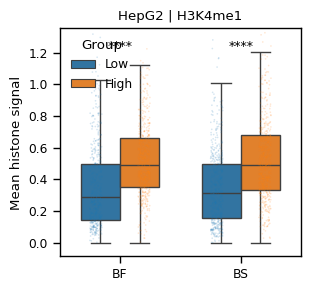

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K4me1_BF_BS_high_low_boxplot.png


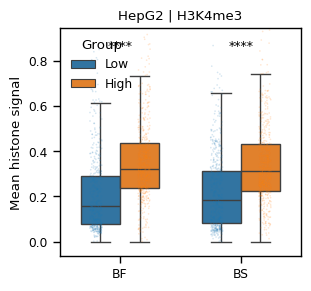

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K4me3_BF_BS_high_low_boxplot.png


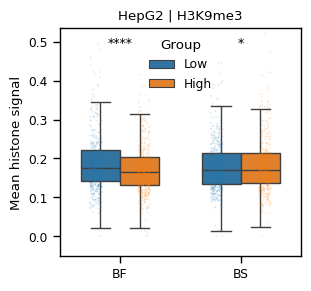

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K9me3_BF_BS_high_low_boxplot.png


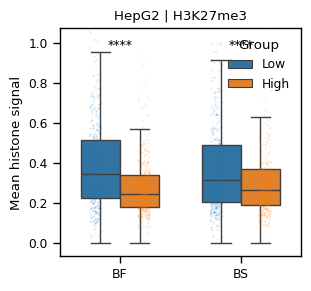

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K27me3_BF_BS_high_low_boxplot.png


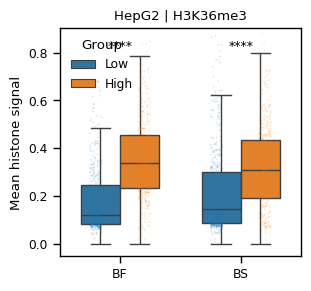

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K36me3_BF_BS_high_low_boxplot.png


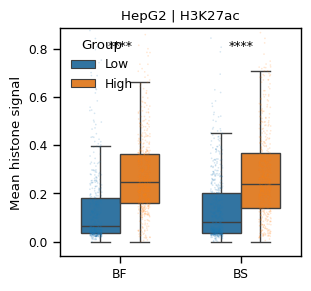

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K27ac_BF_BS_high_low_boxplot.png


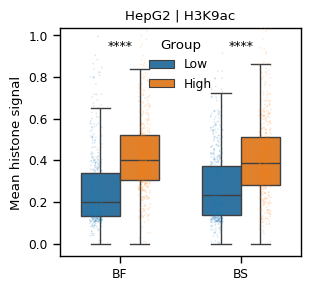

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_H3K9ac_BF_BS_high_low_boxplot.png


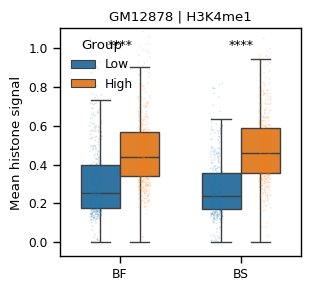

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K4me1_BF_BS_high_low_boxplot.png


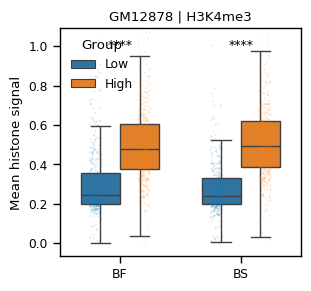

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K4me3_BF_BS_high_low_boxplot.png


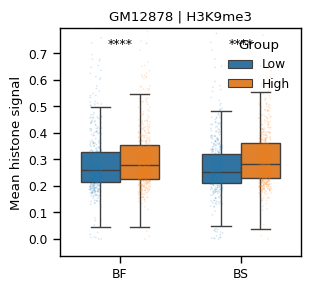

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K9me3_BF_BS_high_low_boxplot.png


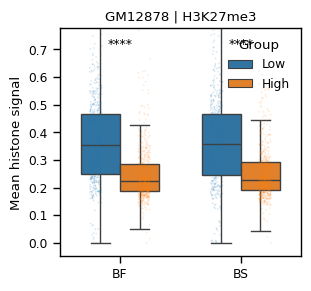

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K27me3_BF_BS_high_low_boxplot.png


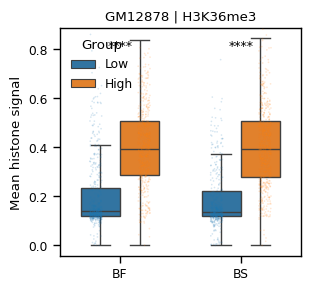

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K36me3_BF_BS_high_low_boxplot.png


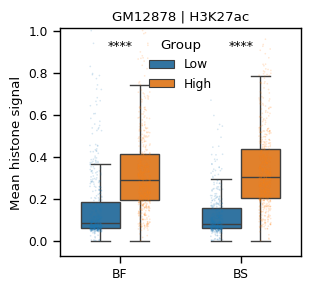

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K27ac_BF_BS_high_low_boxplot.png


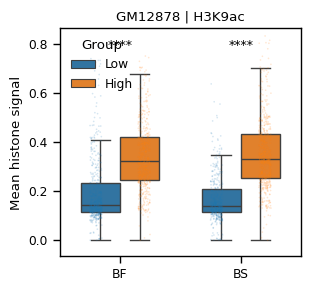

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_H3K9ac_BF_BS_high_low_boxplot.png


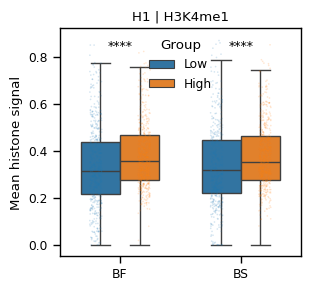

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K4me1_BF_BS_high_low_boxplot.png


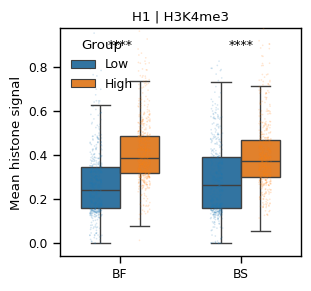

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K4me3_BF_BS_high_low_boxplot.png


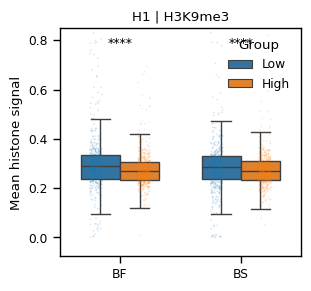

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K9me3_BF_BS_high_low_boxplot.png


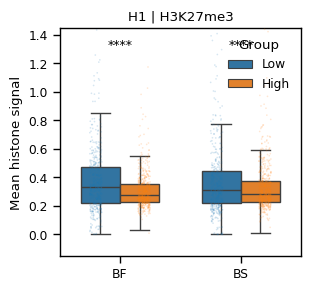

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K27me3_BF_BS_high_low_boxplot.png


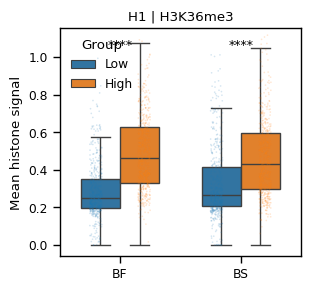

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K36me3_BF_BS_high_low_boxplot.png


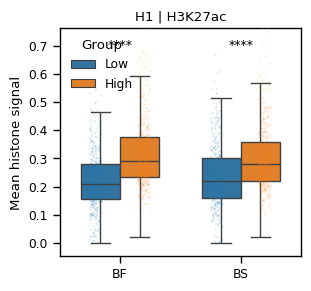

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K27ac_BF_BS_high_low_boxplot.png


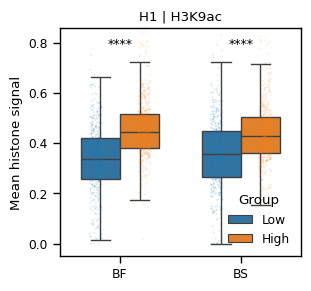

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_H3K9ac_BF_BS_high_low_boxplot.png


In [53]:
for eid in EIDS:
    for mark in MARKS:
        plot_one_celltype_one_mark(
            plot_df=plot_df,
            test_df=test_df,
            eid=eid,
            mark=mark,
            out_dir=out_dir,
        )

In [54]:
def plot_one_celltype_all_marks_subplot(plot_df, test_df, eid, out_dir):
    """
    One figure for one cell type.
    Seven histone marks are shown as subplots.

    Each subplot:
        x-axis: BF, BS
        y-axis: mean histone signal across bins
        hue: Low / High
    """
    cell_type = EID_NAME.get(eid, eid)

    sub_all = plot_df[plot_df["eid"] == eid].copy()

    if len(sub_all) == 0:
        print(f"[Skip] No data for {eid}")
        return

    n_marks = len(MARKS)
    n_cols = 4
    n_rows = int(np.ceil(n_marks / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 6),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)

    for ax_idx, mark in enumerate(MARKS):
        ax = axes[ax_idx]

        sub = sub_all[sub_all["mark"] == mark].copy()

        if len(sub) == 0:
            ax.axis("off")
            continue

        sns.boxplot(
            data=sub,
            x="label_type",
            y="value",
            hue="group",
            order=["BF", "BS"],
            hue_order=["Low", "High"],
            showfliers=False,
            width=0.65,
            linewidth=0.8,
            ax=ax,
        )

        # 为避免点太多，每个 subplot 最多抽样 1200 个点
        strip_sub = sub.sample(
            min(len(sub), 1200),
            random_state=2024,
        )

        sns.stripplot(
            data=strip_sub,
            x="label_type",
            y="value",
            hue="group",
            order=["BF", "BS"],
            hue_order=["Low", "High"],
            dodge=True,
            alpha=0.18,
            size=1.0,
            linewidth=0,
            ax=ax,
        )

        # 去除重复 legend
        handles, labels = ax.get_legend_handles_labels()
        if ax_idx == 0:
            ax.legend(
                handles[:2],
                labels[:2],
                title="Group",
                frameon=False,
                fontsize=8,
                title_fontsize=8,
                loc="best",
            )
        else:
            ax.legend_.remove()

        ax.set_title(mark, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Mean signal" if ax_idx % n_cols == 0 else "")

        # 添加显著性标注
        y_max = sub["value"].quantile(0.98)
        y_min = sub["value"].quantile(0.02)
        y_range = y_max - y_min

        if y_range <= 0 or not np.isfinite(y_range):
            y_range = 1.0

        for x_idx, label_type in enumerate(["BF", "BS"]):
            row = test_df[
                (test_df["eid"] == eid) &
                (test_df["mark"] == mark) &
                (test_df["label_type"] == label_type)
            ]

            if len(row) == 0:
                continue

            fdr = row["fdr"].iloc[0]
            star = p_to_star(fdr)

            ax.text(
                x_idx,
                y_max + 0.08 * y_range,
                star,
                ha="center",
                va="bottom",
                fontsize=9,
            )

        ax.set_ylim(top=y_max + 0.22 * y_range)

    # 删除多余 subplot
    for j in range(n_marks, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{cell_type} ({eid}) | BF/BS high-low histone signal comparison",
        fontsize=13,
        y=1.02,
    )

    plt.tight_layout()

    fig_path = out_dir / f"{eid}_{cell_type}_all_marks_BF_BS_high_low_subplots.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[Saved] {fig_path}")

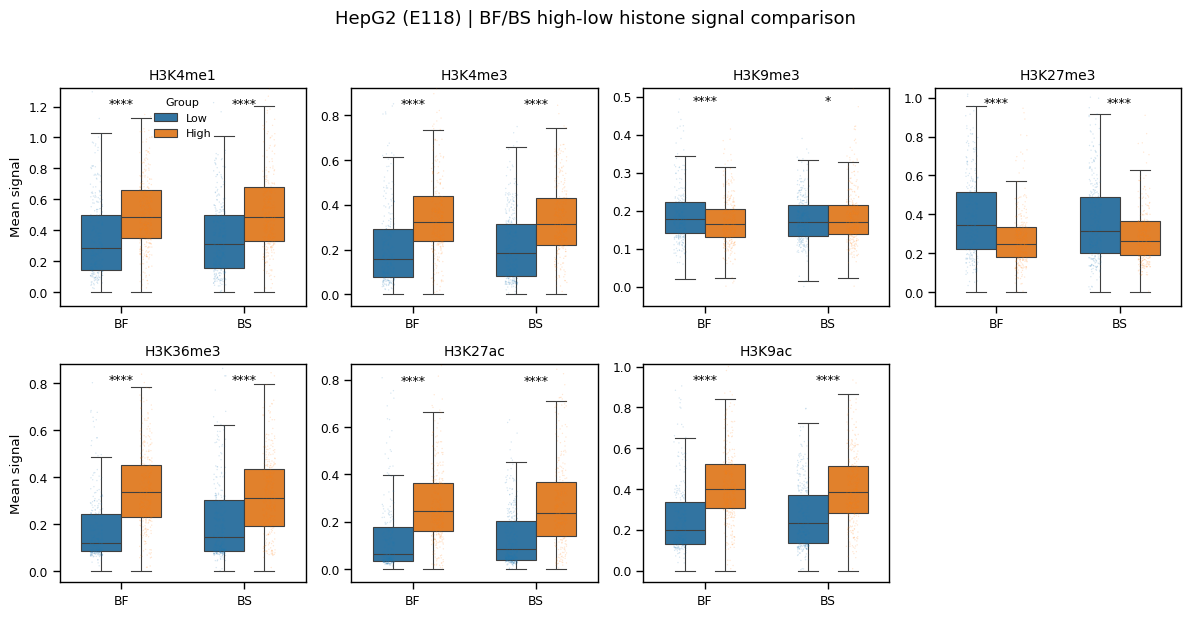

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_all_marks_BF_BS_high_low_subplots.png


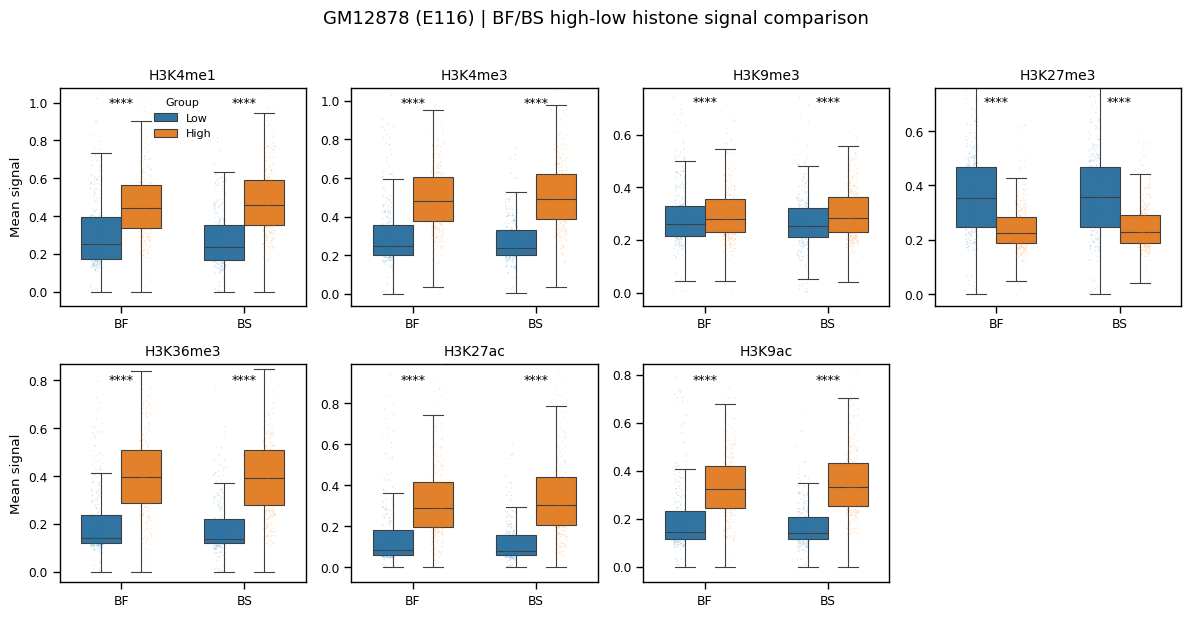

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_all_marks_BF_BS_high_low_subplots.png


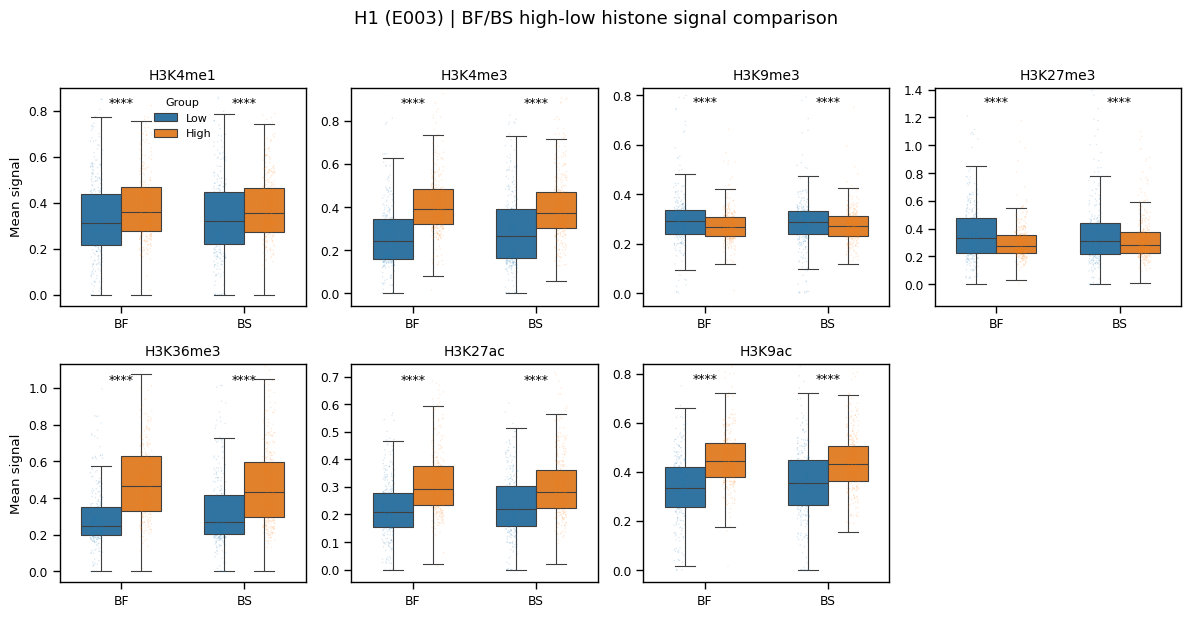

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_all_marks_BF_BS_high_low_subplots.png


In [56]:
for eid in EIDS:
    plot_one_celltype_all_marks_subplot(
        plot_df=plot_df,
        test_df=test_df,
        eid=eid,
        out_dir=out_dir,
    )

In [57]:
median_diff_records = []

for (eid, cell_type, mark, label_type), sub in plot_df.groupby(
    ["eid", "cell_type", "mark", "label_type"]
):
    high_values = sub.loc[sub["group"] == "High", "value"].values
    low_values = sub.loc[sub["group"] == "Low", "value"].values

    high_values = high_values[np.isfinite(high_values)]
    low_values = low_values[np.isfinite(low_values)]

    median_high = np.median(high_values)
    median_low = np.median(low_values)

    median_diff = median_high - median_low
    abs_median_diff = np.abs(median_diff)

    median_diff_records.append({
        "eid": eid,
        "cell_type": cell_type,
        "mark": mark,
        "label_type": label_type,
        "n_high": len(high_values),
        "n_low": len(low_values),
        "median_high": median_high,
        "median_low": median_low,
        "median_high_minus_low": median_diff,
        "abs_median_high_minus_low": abs_median_diff,
    })

median_diff_df = pd.DataFrame(median_diff_records)

median_diff_path = out_dir / "bf_bs_high_low_abs_median_difference.csv"
median_diff_df.to_csv(median_diff_path, index=False)

print(f"[Saved] {median_diff_path}")
median_diff_df

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/bf_bs_high_low_abs_median_difference.csv


,eid,cell_type,mark,label_type,n_high,n_low,median_high,median_low,median_high_minus_low,abs_median_high_minus_low
0,E003,H1,H3K27ac,BF,7309,7111,0.292655,0.208105,0.084550,0.084550
1,E003,H1,H3K27ac,BS,7110,7310,0.280116,0.220787,0.059328,0.059328
2,E003,H1,H3K27me3,BF,7309,7111,0.277382,0.330520,-0.053139,0.053139
3,E003,H1,H3K27me3,BS,7110,7310,0.286154,0.312096,-0.025942,0.025942
4,E003,H1,H3K36me3,BF,7309,7111,0.464579,0.249780,0.214799,0.214799
5,E003,H1,H3K36me3,BS,7110,7310,0.430321,0.266385,0.163936,0.163936
6,E003,H1,H3K4me1,BF,7309,7111,0.358657,0.313165,0.045492,0.045492
7,E003,H1,H3K4me1,BS,7110,7310,0.353571,0.318997,0.034575,0.034575
8,E003,H1,H3K4me3,BF,7309,7111,0.388510,0.239816,0.148693,0.148693
9,E003,H1,H3K4me3,BS,7110,7310,0.372181,0.265165,0.107016,0.107016


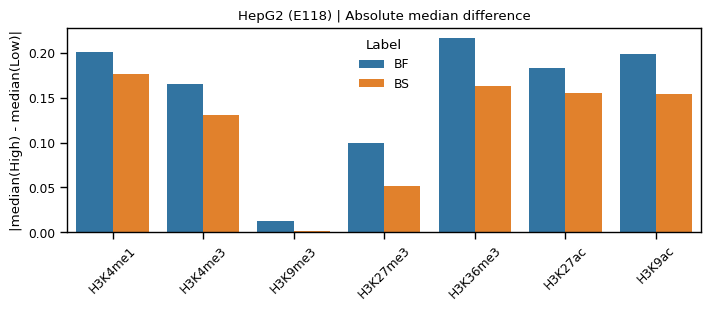

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E118_HepG2_BF_BS_abs_median_difference_barplot.png


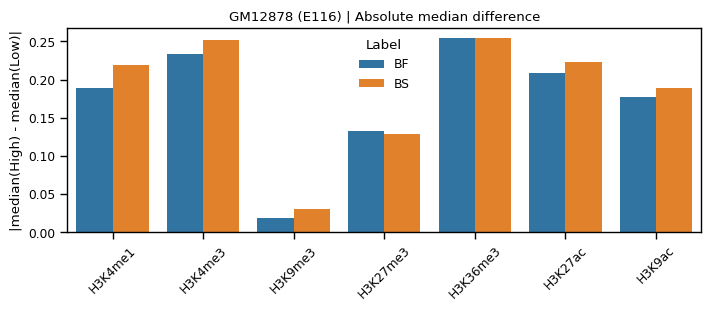

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E116_GM12878_BF_BS_abs_median_difference_barplot.png


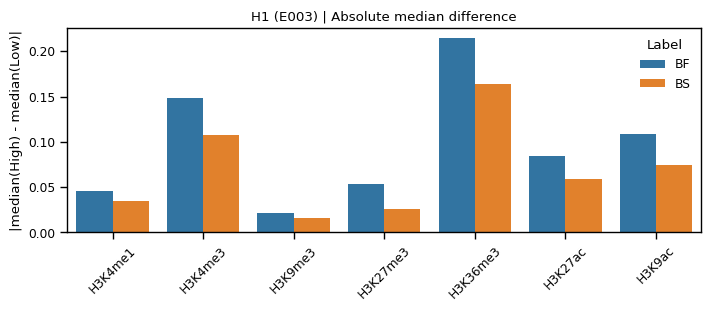

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots/E003_H1_BF_BS_abs_median_difference_barplot.png


In [58]:
def plot_abs_median_diff_barplot(median_diff_df, eid, out_dir):
    """
    For one cell type:
        x-axis: histone marks
        y-axis: |median(High) - median(Low)|
        hue: BF / BS
    """
    cell_type = EID_NAME.get(eid, eid)

    sub = median_diff_df[median_diff_df["eid"] == eid].copy()

    if len(sub) == 0:
        print(f"[Skip] No data for {eid}")
        return

    # 保证组蛋白修饰顺序固定
    sub["mark"] = pd.Categorical(sub["mark"], categories=MARKS, ordered=True)
    sub["label_type"] = pd.Categorical(sub["label_type"], categories=["BF", "BS"], ordered=True)
    sub = sub.sort_values(["mark", "label_type"])

    fig, ax = plt.subplots(figsize=(7.2, 3.2))

    sns.barplot(
        data=sub,
        x="mark",
        y="abs_median_high_minus_low",
        hue="label_type",
        order=MARKS,
        hue_order=["BF", "BS"],
        ax=ax,
    )

    ax.set_xlabel("")
    ax.set_ylabel("|median(High) - median(Low)|")
    ax.set_title(f"{cell_type} ({eid}) | Absolute median difference")

    ax.tick_params(axis="x", rotation=45)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        labels,
        title="Label",
        frameon=False,
        loc="best",
    )

    plt.tight_layout()

    fig_path = out_dir / f"{eid}_{cell_type}_BF_BS_abs_median_difference_barplot.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[Saved] {fig_path}")


for eid in EIDS:
    plot_abs_median_diff_barplot(
        median_diff_df=median_diff_df,
        eid=eid,
        out_dir=out_dir,
    )

In [59]:
# Cell 1: 导入包
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("paper")

In [60]:
# Cell 2: 参数设置
EIDS = ["E118", "E116", "E003"]
EID_NAME = {"E118":"HepG2","E116":"GM12878","E003":"H1"}
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]

result_dir = Path("benchmarks/revised_v2/reviewer3/results")
out_dir = result_dir / "bf_bs_mark_boxplots_subplots"
out_dir.mkdir(parents=True, exist_ok=True)

In [61]:
# Cell 3: 读取 npy 文件并整理成长表
def load_mark_npy(eid, label_type):
    label_lower = label_type.lower()
    high_path = result_dir / f"{eid}_{label_lower}_para_highmarks.npy"
    low_path = result_dir / f"{eid}_{label_lower}_para_lowmarks.npy"
    
    high_arr = np.load(high_path)
    low_arr = np.load(low_path)
    
    records = []
    for i, mark in enumerate(MARKS):
        high_values = np.nanmean(high_arr[:, i, :], axis=1)
        low_values = np.nanmean(low_arr[:, i, :], axis=1)
        for v in high_values:
            records.append({"eid":eid,"cell_type":EID_NAME[eid],"label_type":label_type,
                            "mark":mark,"group":"High","value":v})
        for v in low_values:
            records.append({"eid":eid,"cell_type":EID_NAME[eid],"label_type":label_type,
                            "mark":mark,"group":"Low","value":v})
    return pd.DataFrame(records)

all_df = []
for eid in EIDS:
    for label_type in ["BF","BS"]:
        df = load_mark_npy(eid, label_type)
        all_df.append(df)
plot_df = pd.concat(all_df,ignore_index=True)

In [62]:
# Cell 4: 计算 Mann-Whitney U test，并校正 FDR
def mann_whitney_fdr(df):
    results = []
    for (eid, cell_type, mark, label_type), sub in df.groupby(["eid","cell_type","mark","label_type"]):
        high = sub[sub["group"]=="High"]["value"].values
        low = sub[sub["group"]=="Low"]["value"].values
        stat, p = mannwhitneyu(high, low, alternative="two-sided")
        results.append({"eid":eid,"cell_type":cell_type,"mark":mark,"label_type":label_type,"p":p})
    res_df = pd.DataFrame(results)
    res_df["fdr"] = multipletests(res_df["p"], method="fdr_bh")[1]
    return res_df

test_df = mann_whitney_fdr(plot_df)

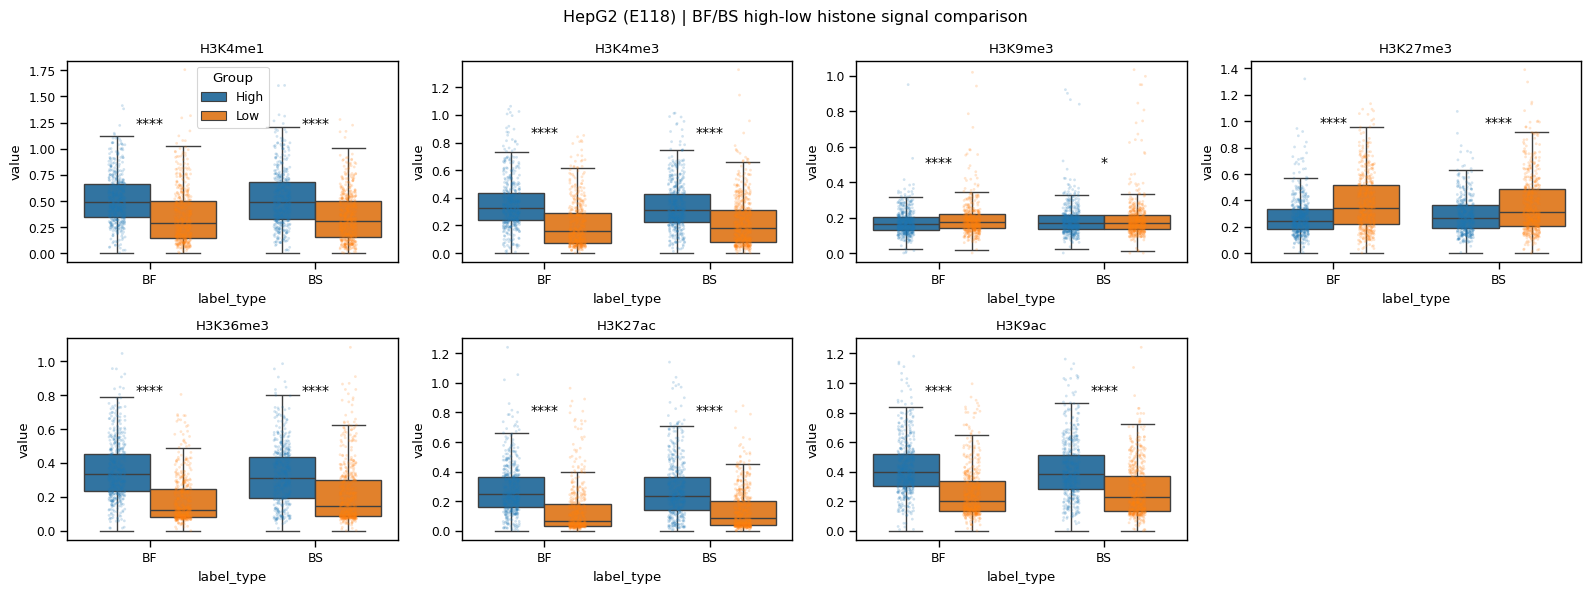

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots_subplots/E118_HepG2_all_marks_BF_BS_subplots.png


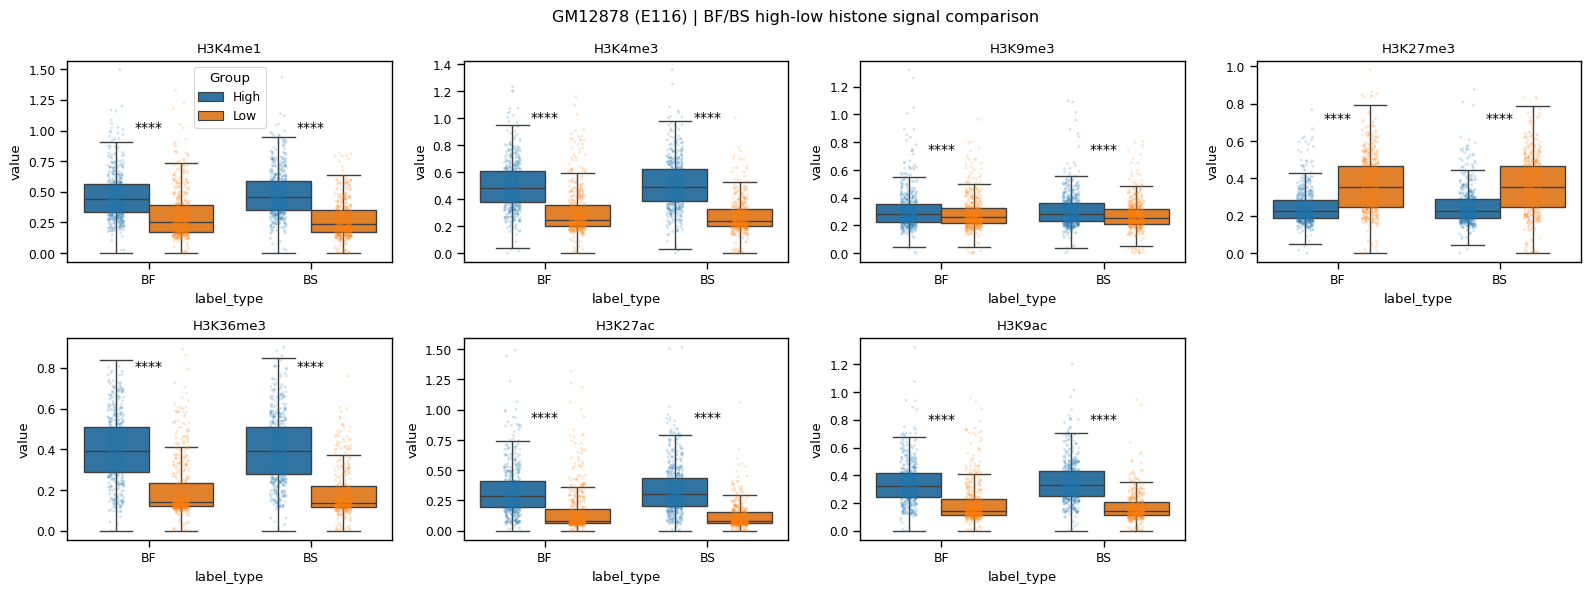

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots_subplots/E116_GM12878_all_marks_BF_BS_subplots.png


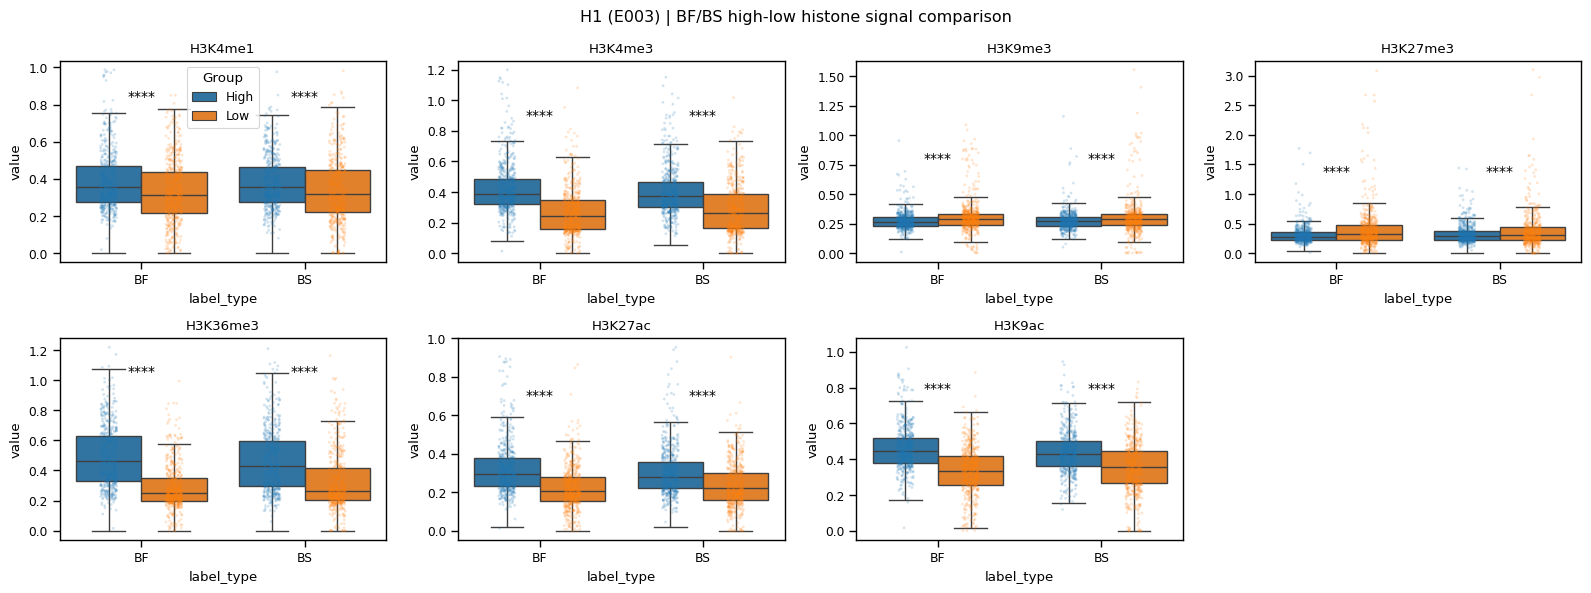

[Saved] benchmarks/revised_v2/reviewer3/results/bf_bs_mark_boxplots_subplots/E003_H1_all_marks_BF_BS_subplots.png


In [63]:
# Cell 5: 绘制每个细胞系 7 个组蛋白 subplot
def p_to_star(p):
    if p<1e-4: return "****"
    elif p<1e-3: return "***"
    elif p<1e-2: return "**"
    elif p<0.05: return "*"
    else: return "ns"

def plot_celltype_subplots(plot_df, test_df, eid):
    cell_type = EID_NAME[eid]
    fig, axes = plt.subplots(2,4,figsize=(16,6))
    axes = axes.flatten()
    for i, mark in enumerate(MARKS):
        ax = axes[i]
        sub = plot_df[(plot_df["eid"]==eid)&(plot_df["mark"]==mark)]
        sns.boxplot(data=sub,x="label_type",y="value",hue="group",showfliers=False,ax=ax)
        sns.stripplot(data=sub.sample(min(len(sub),2000),random_state=2024),x="label_type",y="value",
                      hue="group",dodge=True,alpha=0.2,size=2,ax=ax)
        handles, labels = ax.get_legend_handles_labels()
        if i==0: ax.legend(handles[:2],labels[:2],title="Group")
        else: ax.legend_.remove()
        ax.set_title(mark)
        # 标显著性
        for x_idx, label_type in enumerate(["BF","BS"]):
            row = test_df[(test_df["eid"]==eid)&(test_df["mark"]==mark)&(test_df["label_type"]==label_type)]
            if len(row)==0: continue
            star = p_to_star(row["fdr"].values[0])
            y_max = sub["value"].quantile(0.98)
            y_range = sub["value"].quantile(0.98)-sub["value"].quantile(0.02)
            if not np.isfinite(y_range) or y_range==0: y_range=0.1
            ax.text(x_idx,y_max+0.08*y_range,star,ha="center",va="bottom",fontsize=10)
    for j in range(len(MARKS), len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"{cell_type} ({eid}) | BF/BS high-low histone signal comparison")
    plt.tight_layout()
    path = out_dir/f"{eid}_{cell_type}_all_marks_BF_BS_subplots.png"
    fig.savefig(path,dpi=300,bbox_inches="tight")
    plt.show()
    print(f"[Saved] {path}")

for eid in EIDS:
    plot_celltype_subplots(plot_df,test_df,eid)